In [3]:
#!pip install --upgrade pip setuptools wheel
#!pip install -r requirements.txt --verbose

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# Lecture des données
X_train = pd.read_csv("../data/X_train_update.csv")
y_train = pd.read_csv("../data/Y_train_CVw08PX.csv")
X_test = pd.read_csv("../data/X_test_update.csv")

# Affichage des informations sur les datasets
print(f"Info X_train : {X_train.info()}")
print(f"Info Y_train : {y_train.info()}")
print(f"Info X_test : {X_test.info()}")

# Affichage des tailles des datasets
print(f"Taille X_train : {X_train.shape}")
print(f"Taille Y_train : {y_train.shape}")
print(f"Taille X_test : {X_test.shape}")

# Affichage du nombre de classes dans la variable cible
print(y_train['prdtypecode'].nunique())  # 27 classes

# Merge données d'entrainement
full_data = pd.merge(X_train, y_train, left_index=True, right_index=True)

# Suppression de la colonne Unnamed: 0_y qui est une colonne d'index inutile
full_data = full_data.drop(['Unnamed: 0_y'], axis=1)

# Renomage de la colonne Unnamed: 0_x en id et mise en index de cette colonne
full_data.rename(columns={'Unnamed: 0_x': 'id'}, inplace=True)
full_data.set_index(['id'], inplace=True)

X_test.rename(columns={'Unnamed: 0': 'id'}, inplace=True)
X_test.set_index(['id'], inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   84916 non-null  int64 
 1   designation  84916 non-null  object
 2   description  55116 non-null  object
 3   productid    84916 non-null  int64 
 4   imageid      84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.2+ MB
Info X_train : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   84916 non-null  int64
 1   prdtypecode  84916 non-null  int64
dtypes: int64(2)
memory usage: 1.3 MB
Info Y_train : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13812 entries, 0 to 13811
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   1

In [5]:
# Informations sur les données du dataset d'entrainement
print("Types de données :")
print(full_data.dtypes)
print("\nValeurs manquantes :")
print(full_data.isnull().sum())
print("\nPourcentage de valeurs manquantes :")
print((full_data.isnull().sum() / len(full_data) * 100))

# nan_count = (full_data['description'].astype(str) == 'nan').sum()
# print(f"\nNombre de description NaN : {nan_count}")

Types de données :
designation    object
description    object
productid       int64
imageid         int64
prdtypecode     int64
dtype: object

Valeurs manquantes :
designation        0
description    29800
productid          0
imageid            0
prdtypecode        0
dtype: int64

Pourcentage de valeurs manquantes :
designation     0.000000
description    35.093504
productid       0.000000
imageid         0.000000
prdtypecode     0.000000
dtype: float64


In [6]:
# Statistiques descriptives
print("\nStatistiques descriptives :")
#Longueur des textes
full_data['len_designation'] = (full_data['designation'].astype(str).apply(len))
full_data['len_description'] = (full_data['description'].astype(str).apply(len))

#Nombre de mots
full_data['nb_words_designation'] = (full_data['designation'].astype(str).apply(lambda x: len(x.split())))
full_data['nb_words_description'] = (full_data['description'].astype(str).apply(lambda x: len(x.split())))

# Affichage des statistiques descriptives pour les colonnes de texte
print("\nDESIGNATION")
print(f"Longueur minimale du titre : {full_data['len_designation'].min()} caractères")
print(f"Longueur maximale du titre : {full_data['len_designation'].max()} caractères")
print(f"Longueur moyenne du titre : {full_data['len_designation'].mean():.2f} caractères")
print(f"Longueur médiane du titre : {full_data['len_designation'].median()} caractères")
print(f"Nombre moyen de mots : {full_data['nb_words_designation'].mean():.2f} mots")


print("\nDESCRIPTION")
print(f"Longueur minimale de la description : {full_data['len_description'].min()} caractères")
print(f"Longueur maximale de la description : {full_data['len_description'].max()} caractères")
print(f"Longueur moyenne de la description : {full_data['len_description'].mean():.2f} caractères")
print(f"Longueur médiane de la description : {full_data['len_description'].median()} caractères")
print(f"Nombre moyen de mots : {full_data['nb_words_description'].mean():.2f} mots")


Statistiques descriptives :

DESIGNATION
Longueur minimale du titre : 11 caractères
Longueur maximale du titre : 250 caractères
Longueur moyenne du titre : 70.16 caractères
Longueur médiane du titre : 64.0 caractères
Nombre moyen de mots : 11.56 mots

DESCRIPTION
Longueur minimale de la description : 1 caractères
Longueur maximale de la description : 12451 caractères
Longueur moyenne de la description : 525.61 caractères
Longueur médiane de la description : 231.0 caractères
Nombre moyen de mots : 80.52 mots


In [7]:
# Distribution des catégories
count_cat = full_data['prdtypecode'].value_counts().sort_index()
print(f"Nombre de catégories : {len(count_cat)}")


Nombre de catégories : 27


In [8]:
#Fonction de nettoyage du texte
import re

def clean_text(text):
    if pd.isnull(text):
        return ""

    # Supprimer la ponctuation
    #text = re.sub(r'[^\w\s]', '', text)

    # Supprimer balises HTML
    text = re.sub(r'<.*?>', '', text)

    # Remplacer <br /> par un espace
    text = text.replace(r'<br />', ' ')

    # Remplacer les référence de caractère HTML
    text = text.replace(r'&amp;', '&')
    text = text.replace(r'&nbsp;', ' ')
    text = text.replace(r'&lt', '<')
    text = text.replace(r'&gt', '>')
    text = text.replace(r'&quot', '"')
    text = text.replace(r'&#39', "'")
    text = text.replace(r'&eacute', 'e')
    text = text.replace(r'&egrave', 'e')
    text = text.replace(r'&ecirc', 'e')
    
    # Convertir en minuscules
    text = text.lower()

    # Supprimer les espaces supplémentaires
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [9]:
#Nettoyage du texte
full_data['clean_designation'] = full_data['designation'].apply(clean_text)
full_data['clean_description'] = full_data['description'].apply(clean_text)

#Vérification de doublon dans les désignations et descriptions nettoyées
duplicate_designation = full_data['clean_designation'].duplicated().sum()
duplicate_description = full_data['clean_description'].duplicated().sum()

#Concaténation des désignations et descriptions nettoyées pour l'analyse de texte
full_data['text'] = full_data['clean_designation'] + ' ' + full_data['clean_description']

In [10]:
# Affichage du nombre de doublons
print(duplicate_description)
print(duplicate_designation)


37619
2675


In [11]:
# Compte du nombre de descriptions NaN après nettoyage
nan_count = (full_data['clean_description'].astype(str) == 'nan').sum()
print(f"\nNombre de description NaN : {nan_count}")


Nombre de description NaN : 0


In [12]:
# Création d'un nouveau dataframe pour l'analyse de texte
test_data = full_data.drop(columns=['designation', 'description', 'productid', 'imageid','clean_designation','clean_description', 'len_description', 'len_designation', 'nb_words_description', 'nb_words_designation'], axis=1)
display(test_data.head(20))

,prdtypecode,text
id,,
0,10,olivia: personalisiertes notizbuch / 150 seite...
1,2280,journal des arts (le) n° 133 du 28/09/2001 - l...
2,50,grand stylet ergonomique bleu gamepad nintendo...
3,1280,peluche donald - europe - disneyland 2000 (mar...
4,2705,la guerre des tuques luc a des ide;es de grand...
5,2280,afrique contemporaine n° 212 hiver 2004 - doss...
6,10,christof e: bildungsprozessen auf der spur
7,2522,conquérant sept cahier couverture polypro 240 ...
8,1280,puzzle scooby-doo avec poster 2x35 pieces


In [20]:
full_data.head()

,designation,description,productid,imageid,prdtypecode,len_designation,len_description,nb_words_designation,nb_words_description,clean_designation,clean_description,text
id,,,,,,,,,,,,
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10,88,3,14,1,olivia: personalisiertes notizbuch / 150 seite...,,olivia: personalisiertes notizbuch / 150 seite...
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280,206,3,39,1,journal des arts (le) n° 133 du 28/09/2001 - l...,,journal des arts (le) n° 133 du 28/09/2001 - l...
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,76,760,12,109,grand stylet ergonomique bleu gamepad nintendo...,pilot style touch pen de marque speedlink est ...,grand stylet ergonomique bleu gamepad nintendo...
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280,63,3,10,1,peluche donald - europe - disneyland 2000 (mar...,,peluche donald - europe - disneyland 2000 (mar...
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705,20,213,4,34,la guerre des tuques,luc a des ide;es de grandeur. il veut organise...,la guerre des tuques luc a des ide;es de grand...


In [13]:
# Analyse des langues du jeu de données
# from langdetect import detect, DetectorFactory, LangDetectException
# USE_LANG_DETECT = True  # Mettre à True pour activer la détection de langue
# DetectorFactory.seed = 0  # Pour des résultats reproductibles

# def detect_language(text):
#    if not USE_LANG_DETECT:
#        return 'unknown'
#    try:
#        return detect(text)
#    except (LangDetectException, Exception):
#        return 'unknown'
    

#test_data['language'] = test_data['text'].apply(detect_language)
#print(test_data['language'].value_counts())

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

# Importation de TfidfVectorizer pour la vectorisation du texte
vectorizer = TfidfVectorizer()

# Création des ensembles d'entraînement et de test pour l'analyse de texte (20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(full_data['text'], full_data['prdtypecode'], test_size=0.2, random_state=42)

# Vectorisation du texte
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [15]:
# Test de modèle KNN sur les données vectorisées
# Création du classifieur KNN
clf = KNeighborsClassifier(n_neighbors=5)

# Entraînement du classifieur
clf.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred = clf.predict(X_test)

# Évaluation de la précision du classifieur
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du classifieur KNN : {accuracy:.4f}")

# Matrice de confusion
cm = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
print("Matrice de confusion :")
print(cm)


Précision du classifieur KNN : 0.7267
Matrice de confusion :
Predicted  10    40    50    60    1140  1160  1180  1280  1281  1300  ...  \
Actual                                                                 ...   
10          417    19     4     1     4     9     0     7     4     3  ...   
40          106   300    15     7    13     3     3     7     7     3  ...   
50            8    26   247     1     3     0     0     0     0     8  ...   
60            4     4    10   133     0     0     0     0     0     0  ...   
1140         57    30     6     0   360    13     5    17     5     3  ...   
1160         44     9     3     0    10   703     3     2     4     0  ...   
1180         27     3     1     0     9     5    84     5     2     1  ...   
1280        100    16     4     2    53     7     2   474    52   144  ...   
1281         69    10     3     0    15    12    10    93   151     2  ...   
1300         23     3     2     0     6     0     0    86     1   834  ...   
130

In [16]:
# Test de différents k et différentes métriques pour le KNN
from sklearn import neighbors

score_minko = []
score_man = []
score_cheb = []

for k in range (1,11):
    knn_minko = neighbors.KNeighborsClassifier(n_neighbors=k, metric='minkowski')
    knn_minko.fit(X_train, y_train)
    score_minko.append(knn_minko.score(X_test, y_test))

for k in range (1,11):
    knn_man = neighbors.KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn_man.fit(X_train, y_train)
    score_man.append(knn_man.score(X_test, y_test))

for k in range (1,11):
    knn_cheb = neighbors.KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_cheb.fit(X_train, y_train)
    score_cheb.append(knn_cheb.score(X_test, y_test))

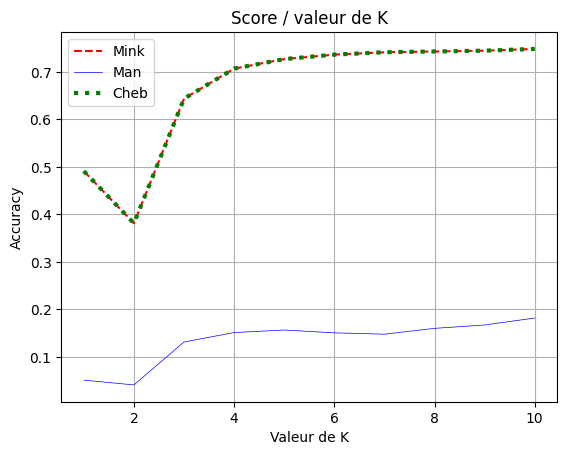

In [17]:
# Affichage dans un graphique les scores des différents métriques en fonction de K
plt.plot(range(1,11), score_minko, color='red', linestyle='--', label='Mink')
plt.plot(range(1,11), score_man, color='blue', linestyle='-',lw=0.5, label='Man')
plt.plot(range(1,11), score_cheb, color='green', linestyle=':', lw=3, label='Cheb') 

plt.legend()
plt.title('Score / valeur de K')
plt.xlabel('Valeur de K')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

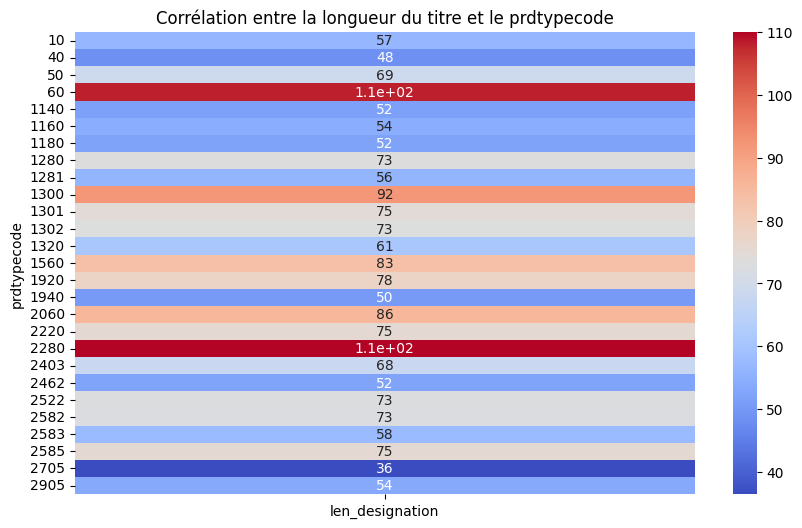

In [21]:
# Heatmap corrélation longueur du titre vs prdtypecode -> corrélation de pearson < 0.2 -> on peut conclure que la longueur du texte n'est pas un bon indicateur pour différencier les classes de produits
plt.figure(figsize=(10,6))
pivot = full_data.pivot_table(index='prdtypecode', values='len_designation', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Corrélation entre la longueur du titre et le prdtypecode')
plt.show()